In [2]:
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import re
import tensorflow_datasets as tfds
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Utils

In [3]:
def eval_model(model, x, y):
    loss, acc = model.evaluate(x, y, verbose=0)
    print(f"Test Accuracy: {acc:.4f}")

    y_pred_prob = model.predict(x)
    y_pred = (y_pred_prob > 0.5).astype(int)

    print(classification_report(y, y_pred))

In [4]:
def plot_train_history(history):
    plt.plot(history.history['accuracy'], label='Train acc')
    plt.plot(history.history['val_accuracy'], label='Val acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training History")
    plt.grid(True)
    plt.show()

# Data: IMDB Reviews negative/positive classification

In [5]:
dataset, info = tfds.load("imdb_reviews", split=["train", "test"], with_info=True, as_supervised=True)
train_data, test_data = dataset

In [6]:
def tfds_to_numpy(dataset):
    texts, labels = [], []
    for text, label in tfds.as_numpy(dataset):
        texts.append(text.decode("utf-8"))
        labels.append(label)
    return texts, np.array(labels)

train_texts, train_labels = tfds_to_numpy(train_data)
test_texts, test_labels = tfds_to_numpy(test_data)

2025-06-17 22:57:24.348406: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-17 22:57:25.612054: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
print("Train example:", train_texts[0])
print("Label:", train_labels[0])  # 0 = neg, 1 = pos


Train example: This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
Label: 0


# Word2Vec + Simple Feed-forward NN

In [12]:
# downloaded from https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
w2v_model = KeyedVectors.load_word2vec_format("glove.6B/glove.6B.300d.txt", binary=False, no_header=True)

In [13]:
import re
from tqdm import tqdm

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

def text_to_vector(text, model):
    tokens = tokenize(text)
    vectors = [model[word] for word in tokens if word in model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

X_train = np.array([text_to_vector(text, w2v_model) for text in tqdm(train_texts, desc="Vectorizing train")])
X_test  = np.array([text_to_vector(text, w2v_model) for text in tqdm(test_texts, desc="Vectorizing test")])

Vectorizing test: 100%|██████████| 25000/25000 [00:05<00:00, 4566.51it/s]


In [14]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [40]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # для бинарной классификации
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

/Users/timbarvenov/Documents/uam/uczenie_glebokie/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=128
)

Epoch 1/1000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8800 - loss: 0.2919 - val_accuracy: 0.8430 - val_loss: 0.3782
Epoch 2/1000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8841 - loss: 0.2851 - val_accuracy: 0.8406 - val_loss: 0.3708
Epoch 3/1000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8846 - loss: 0.2882 - val_accuracy: 0.8404 - val_loss: 0.3717
Epoch 4/1000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8855 - loss: 0.2825 - val_accuracy: 0.8418 - val_loss: 0.3790
Epoch 5/1000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8843 - loss: 0.2905 - val_accuracy: 0.8456 - val_loss: 0.3751
Epoch 6/1000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8847 - loss: 0.2853 - val_accuracy: 0.8414 - val_loss: 0.3753
Epoch 7/1000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8813 - loss: 0.2883 - val_accuracy: 0.8392 - val_loss: 0.3836
Epoch 8/1000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8853 - loss: 0.2844 - 

In [60]:
eval_model(model, X_test, y_test)

Test Accuracy: 0.8190
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 253us/step
              precision    recall  f1-score   support

           0       0.81      0.83      0.82     12500
           1       0.83      0.81      0.82     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



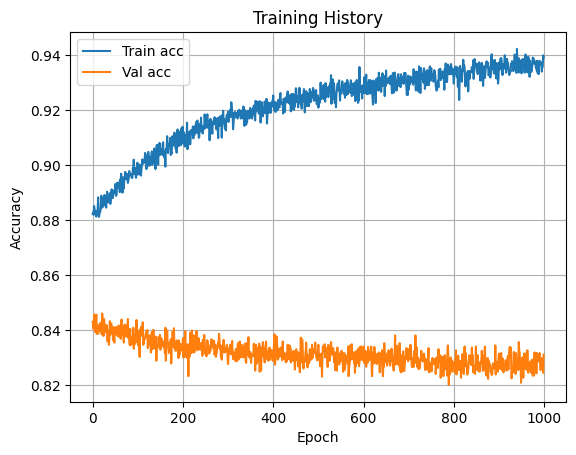

In [62]:
plot_train_history(history)

# RNN + Tokenization

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [9]:
VOCAB_SIZE = 10000
MAX_LENGTH = 200

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq = tokenizer.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

In [22]:
model_rnn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LENGTH),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

/Users/timbarvenov/Documents/uam/uczenie_glebokie/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.5100 - loss: 0.6931 - val_accuracy: 0.5788 - val_loss: 0.6923
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - accuracy: 0.6025 - loss: 0.6620 - val_accuracy: 0.6180 - val_loss: 0.6593
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - accuracy: 0.5950 - loss: 0.6708 - val_accuracy: 0.6084 - val_loss: 0.6562
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.6229 - loss: 0.6348 - val_accuracy: 0.7230 - val_loss: 0.5874
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.7143 - loss: 0.5922 - val_accuracy: 0.7900 - val_loss: 0.4988
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 150ms/step - accuracy: 0.8391 - loss: 0.4189 - val_accuracy: 0.7886 - val_loss: 0.4630
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.8792 - loss: 0.3275 - val_accuracy: 0.8332 - val_loss: 0.3917
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.9083 - loss: 0

## with dropout 0.3

In [19]:
eval_model(model_rnn, X_test_pad, y_test)

Test Accuracy: 0.7940
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step
              precision    recall  f1-score   support

           0       0.77      0.84      0.80     12500
           1       0.82      0.75      0.79     12500

    accuracy                           0.79     25000
   macro avg       0.80      0.79      0.79     25000
weighted avg       0.80      0.79      0.79     25000



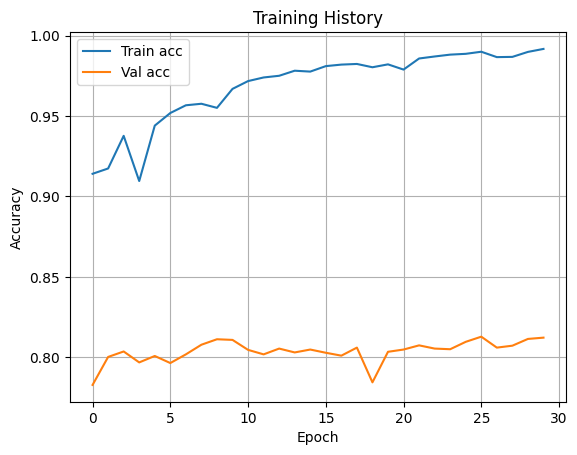

In [20]:
plot_train_history(history_rnn)

## with dropout 0.5

In [24]:
eval_model(model_rnn, X_test_pad, y_test)

Test Accuracy: 0.8255
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step
              precision    recall  f1-score   support

           0       0.81      0.85      0.83     12500
           1       0.84      0.80      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



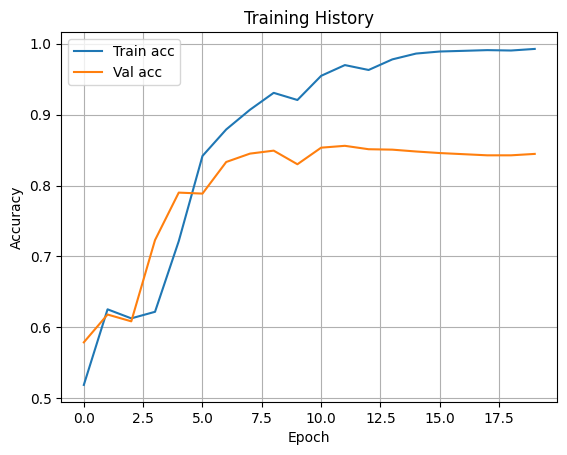

In [25]:
plot_train_history(history_rnn)